In [1]:
# Clone repo for lib/ access (Colab only)
import os, subprocess

if 'google.colab' in str(get_ipython()):
    REPO_DIR = '/content/trading-strategies'
    if not os.path.exists(os.path.join(REPO_DIR, 'lib', 'data_manager.py')):
        # Clean up any failed partial clone
        if os.path.exists(REPO_DIR):
            import shutil
            shutil.rmtree(REPO_DIR)

        # Try public clone first, then fall back to token auth
        result = subprocess.run(
            ['git', 'clone', 'https://github.com/r-giov/trading-strategies.git', REPO_DIR],
            capture_output=True, text=True
        )

        if result.returncode != 0:
            # Private repo — use Colab secrets or userdata for GitHub token
            try:
                from google.colab import userdata
                token = userdata.get('GITHUB_TOKEN')
            except Exception:
                token = None

            if not token:
                raise RuntimeError(
                    "Git clone failed (repo may be private).\n"
                    "Add a GitHub Personal Access Token as a Colab secret named 'GITHUB_TOKEN':\n"
                    "  1. Click the key icon in the left sidebar\n"
                    "  2. Add secret: Name='GITHUB_TOKEN', Value=your_token\n"
                    "  3. Toggle 'Notebook access' ON\n"
                    "  4. Re-run this cell"
                )

            auth_result = subprocess.run(
                ['git', 'clone', f'https://{token}@github.com/r-giov/trading-strategies.git', REPO_DIR],
                capture_output=True, text=True
            )
            if auth_result.returncode != 0:
                raise RuntimeError(f"Git clone failed even with token:\n{auth_result.stderr}")

    # Verify lib exists
    assert os.path.isfile(os.path.join(REPO_DIR, 'lib', 'data_manager.py')), \
        f"Clone succeeded but lib/data_manager.py not found! Check repo structure."

    os.chdir(REPO_DIR)
    print(f"Repo ready at {REPO_DIR}")
    print(f"  lib/ contents: {os.listdir(os.path.join(REPO_DIR, 'lib'))}")
else:
    print("Not running in Colab — skipping clone")

Not running in Colab — skipping clone


In [2]:
# !pip install yfinance
# !pip install TA-Lib
# !pip install numpy
# !pip install pandas
# !pip install vectorbt
# !pip install scipy
# !pip install matplotlib
# !pip install alpaca-py

In [3]:
import sys, os

# Force repo root onto sys.path (works regardless of cwd)
_repo = '/content/trading-strategies'
if os.path.isdir(os.path.join(_repo, 'lib')):
    if _repo not in sys.path:
        sys.path.insert(0, _repo)
else:
    # Local / non-Colab fallback
    _parent = os.path.join(os.getcwd(), '..')
    if os.path.isdir(os.path.join(_parent, 'lib')) and _parent not in sys.path:
        sys.path.insert(0, os.path.abspath(_parent))

import yfinance as yf
import talib
import numpy as np
import pandas as pd
import vectorbt as vbt
import warnings
from scipy import stats
import matplotlib.pyplot as plt
from itertools import product
from lib.data_manager import download, download_multi, setup_colab_secrets

warnings.filterwarnings('ignore')
pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 140)

print(f"\nPackages: vectorbt={vbt.__version__}, pandas={pd.__version__}, numpy={np.__version__}")
print("All imports loaded")


Packages: vectorbt=0.28.1, pandas=2.3.2, numpy=2.3.3
All imports loaded


In [4]:
# ═══════════════════════════════════════════════════════════════
# CONFIGURATION — Opening Range Breakout (ORB)
# ═══════════════════════════════════════════════════════════════

TICKERS = ['QQQ', 'SPY', 'NVDA', 'AAPL', 'MSFT', 'AMD', 'META', 'AMZN']
PRIMARY_TICKER = 'QQQ'
START_DATE = '2024-01-01'  # 1h data goes back ~1 year on Alpaca

# Download multi-asset 1-hour bars via Alpaca
print(f"Downloading 1-hour bars for {len(TICKERS)} tickers from {START_DATE}...\n")
all_data = download_multi(TICKERS, START_DATE, timeframe='1h')

stock_data = all_data[PRIMARY_TICKER]
TICKER = PRIMARY_TICKER

print(f"\nLoaded {len(all_data)} assets")
print(f"Primary ticker: {TICKER} — {len(stock_data)} hourly bars")
print(f"Date range: {stock_data.index[0]} to {stock_data.index[-1]}")
stock_data.head(10)


  QQQ: 4767 1h bars (2024-01-02 13:00:00 to 2026-03-06 21:00:00) via Alpaca
  SPY: 4452 1h bars (2024-01-02 14:00:00 to 2026-03-06 21:00:00) via Alpaca
  NVDA: 4351 1h bars (2024-01-02 14:00:00 to 2026-03-06 21:00:00) via Alpaca
  AAPL: 3971 1h bars (2024-01-02 13:00:00 to 2026-03-06 20:00:00) via Alpaca
  MSFT: 3914 1h bars (2024-01-02 14:00:00 to 2026-03-06 21:00:00) via Alpaca
  AMD: 4039 1h bars (2024-01-02 14:00:00 to 2026-03-06 21:00:00) via Alpaca
  META: 3902 1h bars (2024-01-02 14:00:00 to 2026-03-06 20:00:00) via Alpaca
  AMZN: 3902 1h bars (2024-01-02 14:00:00 to 2026-03-06 20:00:00) via Alpaca

Loaded 8 assets
Primary ticker: QQQ — 4767 hourly bars
Date range: 2024-01-02 13:00:00 to 2026-03-06 21:00:00


,Open,High,Low,Close,Volume,VWAP
Date,,,,,,
2024-01-02 13:00:00,405.480,405.70,405.14,405.630,4414,405.468810
2024-01-02 14:00:00,405.430,406.19,402.51,403.520,148961,403.979451
2024-01-02 15:00:00,403.575,404.13,401.78,402.385,199349,402.674242
2024-01-02 16:00:00,402.340,404.15,402.34,403.950,191488,403.473519
2024-01-02 17:00:00,403.970,404.18,402.53,402.630,100683,403.525421
2024-01-02 18:00:00,402.550,403.10,401.86,402.000,105688,402.641241
2024-01-02 19:00:00,401.990,402.25,400.96,400.960,124267,401.676500
2024-01-02 20:00:00,401.065,402.68,400.26,402.600,411752,401.635699
2024-01-02 21:00:00,402.790,402.93,402.76,402.760,10358,402.839417


Opening Range computed for 545 trading days

Opening Range Statistics:
   Average OR Range:  $3.20 (0.626%)
   Median OR Range:   $2.80 (0.543%)
   Std Dev OR Range:  $2.00
   Min OR Range:      $0.61
   Max OR Range:      $28.64


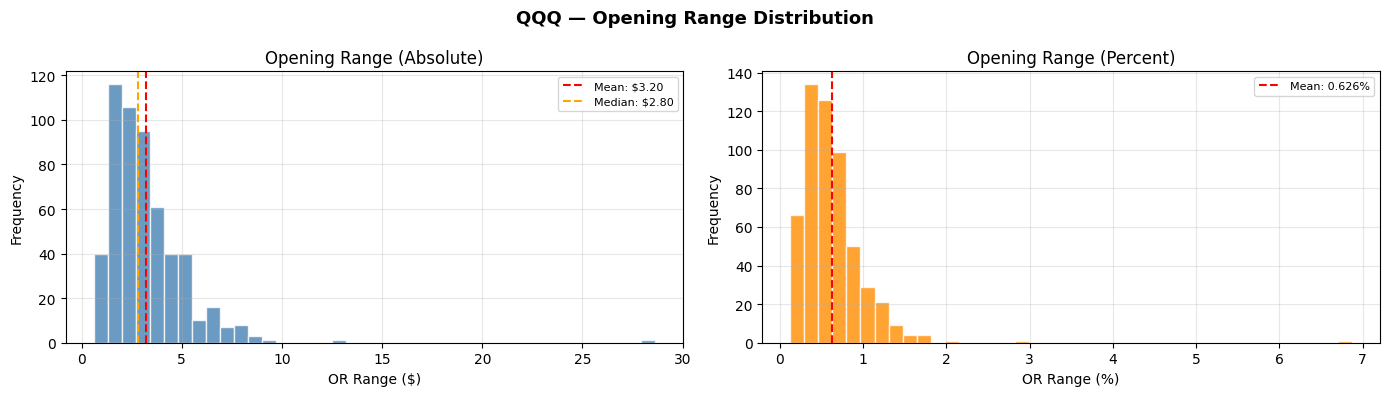

,OR_High,OR_Low,OR_Open,OR_Close,OR_Range,OR_Range_Pct
date,,,,,,
2026-02-23,607.94,603.65,605.67,604.98,4.29,0.708307
2026-02-24,606.21,599.81,603.81,604.11,6.40,1.059936
2026-02-25,615.64,610.46,610.82,615.52,5.18,0.848040
2026-02-26,616.94,611.75,616.61,611.98,5.19,0.841699
2026-02-27,605.88,602.20,603.92,604.66,3.68,0.609352
2026-03-02,605.00,598.03,598.26,604.16,6.97,1.165045
2026-03-03,599.33,594.74,594.96,595.18,4.59,0.771480
2026-03-04,606.90,603.52,604.76,605.74,3.38,0.558899
2026-03-05,612.23,606.99,607.78,612.21,5.24,0.862154


In [5]:
# ═══════════════════════════════════════════════════════════════
# COMPUTE OPENING RANGE FOR EACH TRADING DAY
# ═══════════════════════════════════════════════════════════════
# US market hours in UTC: ~14:30–21:00 (regular session)
# The first 1-hour bar starting at or after 14:00 UTC = Opening Range
# For Alpaca IEX feed, bars align to clock hours (14:00, 15:00, etc.)

df = stock_data.copy()
df['hour_utc'] = df.index.hour
df['date'] = df.index.date

# Filter to US regular trading hours only (14:00 - 20:00 UTC covers 9:30 AM - 4 PM ET)
# Alpaca 1h bars: 14:00 = 9:30-10:30 ET (first bar), ..., 19:00 = 3:00-4:00 ET (last bar)
market_hours = df[(df['hour_utc'] >= 14) & (df['hour_utc'] <= 19)].copy()

# First bar of each day = Opening Range
or_bars = market_hours.groupby('date').first()
or_bars = or_bars.rename(columns={'High': 'OR_High', 'Low': 'OR_Low', 'Open': 'OR_Open', 'Close': 'OR_Close'})
or_bars['OR_Range'] = or_bars['OR_High'] - or_bars['OR_Low']
or_bars['OR_Range_Pct'] = or_bars['OR_Range'] / or_bars['OR_Open'] * 100

opening_ranges = or_bars[['OR_High', 'OR_Low', 'OR_Open', 'OR_Close', 'OR_Range', 'OR_Range_Pct']].copy()

print(f"Opening Range computed for {len(opening_ranges)} trading days")
print(f"\nOpening Range Statistics:")
print(f"   Average OR Range:  ${opening_ranges['OR_Range'].mean():.2f} ({opening_ranges['OR_Range_Pct'].mean():.3f}%)")
print(f"   Median OR Range:   ${opening_ranges['OR_Range'].median():.2f} ({opening_ranges['OR_Range_Pct'].median():.3f}%)")
print(f"   Std Dev OR Range:  ${opening_ranges['OR_Range'].std():.2f}")
print(f"   Min OR Range:      ${opening_ranges['OR_Range'].min():.2f}")
print(f"   Max OR Range:      ${opening_ranges['OR_Range'].max():.2f}")

# Plot range distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'{TICKER} — Opening Range Distribution', fontsize=13, fontweight='bold')

axes[0].hist(opening_ranges['OR_Range'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(opening_ranges['OR_Range'].mean(), color='red', linestyle='--', label=f"Mean: ${opening_ranges['OR_Range'].mean():.2f}")
axes[0].axvline(opening_ranges['OR_Range'].median(), color='orange', linestyle='--', label=f"Median: ${opening_ranges['OR_Range'].median():.2f}")
axes[0].set_xlabel('OR Range ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Opening Range (Absolute)')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].hist(opening_ranges['OR_Range_Pct'], bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(opening_ranges['OR_Range_Pct'].mean(), color='red', linestyle='--', label=f"Mean: {opening_ranges['OR_Range_Pct'].mean():.3f}%")
axes[1].set_xlabel('OR Range (%)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Opening Range (Percent)')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

opening_ranges.tail(10)

In [6]:
# ═══════════════════════════════════════════════════════════════
# PREPARE PRICE SERIES — IS/OOS SPLIT (60/40)
# ═══════════════════════════════════════════════════════════════

TRAIN_RATIO = 0.60
INIT_CASH   = 100_000
FEES        = 0.0005
SLIPPAGE    = 0.0005

# Filter to market hours for the primary ticker
df_mkt = stock_data.copy()
df_mkt['hour_utc'] = df_mkt.index.hour
df_mkt = df_mkt[(df_mkt['hour_utc'] >= 14) & (df_mkt['hour_utc'] <= 19)].copy()
df_mkt = df_mkt.drop(columns=['hour_utc'])

hourly_close = df_mkt['Close'].astype(float)
hourly_high  = df_mkt['High'].astype(float)
hourly_low   = df_mkt['Low'].astype(float)
hourly_open  = df_mkt['Open'].astype(float)

# Split
split_idx = int(len(hourly_close) * TRAIN_RATIO)
train_close = hourly_close.iloc[:split_idx]
val_close   = hourly_close.iloc[split_idx:]
train_df    = df_mkt.iloc[:split_idx]
val_df      = df_mkt.iloc[split_idx:]

print(f"Hourly bars (market hours only): {len(df_mkt)}")
print(f"Train/Val split at index {split_idx} ({TRAIN_RATIO:.0%}/{1-TRAIN_RATIO:.0%})")
print(f"   Train: {len(train_close)} bars | {train_close.index[0]} -> {train_close.index[-1]}")
print(f"   Val:   {len(val_close)} bars  | {val_close.index[0]} -> {val_close.index[-1]}")

# Prepare daily close for portfolio tracking / FTMO MC
daily_close_full = df_mkt.groupby(df_mkt.index.date)['Close'].last()
daily_close_full.index = pd.to_datetime(daily_close_full.index)
daily_close_full = daily_close_full.astype(float)
print(f"\nDaily close series: {len(daily_close_full)} days")

Hourly bars (market hours only): 3258
Train/Val split at index 1954 (60%/40%)
   Train: 1954 bars | 2024-01-02 14:00:00 -> 2025-04-23 19:00:00
   Val:   1304 bars  | 2025-04-24 14:00:00 -> 2026-03-06 19:00:00

Daily close series: 545 days


## Opening Range Breakout (ORB) — Strategy Description

**Concept:** The Opening Range (OR) is the high and low of the first 1-hour bar of the regular trading session. Price breaking above the OR high suggests bullish momentum; breaking below suggests bearish.

**Entry (Long only):**
- Price closes above OR_High on a subsequent hourly bar during the same day
- The previous bar must NOT have already triggered an entry (anti-lookahead)
- Optional range filter: skip days where OR_Range > `range_filter_mult` x rolling 20-day avg range (abnormally wide openings are traps)

**Exit:**
- **Stop Loss:** Entry price minus `stop_mult` x OR_Range
- **Take Profit:** Entry price plus `target_mult` x OR_Range
- **End of Day:** If still in trade at the last bar of the day, exit at close (no overnight holds)

**Parameters to Optimize:**
| Parameter | Description | Range |
|---|---|---|
| `stop_mult` | Stop loss = entry - stop_mult * OR_Range | 0.3, 0.5, 0.75, 1.0 |
| `target_mult` | Target = entry + target_mult * OR_Range | 1.0, 1.5, 2.0, 2.5, 3.0 |
| `range_filter_mult` | Skip if OR_Range > mult * 20d avg range | 1.0, 1.5, 2.0, 999 (=off) |

**Key Characteristics:**
- Pure intraday strategy — no overnight risk
- Self-adapting: OR_Range scales with volatility
- Typical 1-2 trades per day (long side only)
- Edge comes from morning momentum continuation

In [7]:
# ═══════════════════════════════════════════════════════════════
# SIGNAL ENGINE — Opening Range Breakout (bar-by-bar simulation)
# ═══════════════════════════════════════════════════════════════

def generate_orb_signals(hourly_df, stop_mult=0.5, target_mult=2.0, range_filter_mult=1.5):
    """
    Opening Range Breakout on hourly bars (bar-by-bar simulation).

    For each trading day:
    1. First bar of the session = Opening Range (OR_High, OR_Low)
    2. Subsequent bars: if PREVIOUS bar's Close > OR_High -> entry signal (long)
    3. Exit conditions (checked on current bar using previous bar state):
       - Stop loss: price drops below entry - stop_mult * OR_Range
       - Take profit: price rises above entry + target_mult * OR_Range
       - End of day: last bar of the session

    Uses PREVIOUS bar values for all signal decisions (anti-lookahead).
    Returns boolean Series for entries and exits, aligned to hourly index.
    """
    df = hourly_df.copy()
    df['date'] = df.index.date
    df['hour_utc'] = df.index.hour

    # Filter to market hours
    df = df[(df['hour_utc'] >= 14) & (df['hour_utc'] <= 19)].copy()

    n = len(df)
    entries = np.zeros(n, dtype=bool)
    exits = np.zeros(n, dtype=bool)

    close = df['Close'].values.astype(float)
    high  = df['High'].values.astype(float)
    low   = df['Low'].values.astype(float)
    dates = df['date'].values

    # Pre-compute rolling average OR range (20-day lookback) for range filter
    # First, compute OR range per day
    day_groups = df.groupby('date')
    or_highs = {}
    or_lows = {}
    or_ranges = {}
    for day, grp in day_groups:
        first_idx = grp.index[0]
        or_highs[day] = df.loc[first_idx, 'High']
        or_lows[day]  = df.loc[first_idx, 'Low']
        or_ranges[day] = or_highs[day] - or_lows[day]

    # Rolling 20-day average of OR ranges
    or_range_series = pd.Series(or_ranges).sort_index()
    rolling_avg_range = or_range_series.rolling(20, min_periods=5).mean()

    # Bar-by-bar simulation
    in_trade = False
    entry_price = 0.0
    stop_price = 0.0
    target_price = 0.0
    current_day = None
    or_high = 0.0
    or_low = 0.0
    or_range = 0.0
    is_first_bar = True
    day_filtered = False

    for i in range(n):
        day = dates[i]

        # New day detected
        if day != current_day:
            # If we were in a trade from the previous day, exit at the last bar
            # (This should have been handled at EOD below, but safety net)
            if in_trade and i > 0:
                exits[i - 1] = True
                in_trade = False

            current_day = day
            is_first_bar = True
            day_filtered = False

            # Set Opening Range from first bar
            or_high = high[i]
            or_low = low[i]
            or_range = or_high - or_low

            # Range filter: skip days with abnormally wide OR
            if range_filter_mult < 900:  # 999 = no filter
                avg_r = rolling_avg_range.get(day, np.nan)
                if not np.isnan(avg_r) and avg_r > 0 and or_range > range_filter_mult * avg_r:
                    day_filtered = True

            continue  # First bar is the OR itself, no trading on it

        is_first_bar = False

        # Check if this day is filtered out
        if day_filtered:
            continue

        if in_trade:
            # Check exits using PREVIOUS bar's close and current bar's low/high
            # Stop loss: low of current bar touches stop
            if low[i] <= stop_price:
                exits[i] = True
                in_trade = False
                continue

            # Take profit: high of current bar touches target
            if high[i] >= target_price:
                exits[i] = True
                in_trade = False
                continue

            # End of day: check if this is the last bar of the day
            if i + 1 < n and dates[i + 1] != day:
                exits[i] = True
                in_trade = False
                continue
            elif i + 1 >= n:
                # Last bar of entire dataset
                exits[i] = True
                in_trade = False
                continue

        else:
            # Check entry using PREVIOUS bar's close (anti-lookahead)
            if i > 0 and close[i - 1] > or_high and or_range > 0:
                entries[i] = True
                in_trade = True
                entry_price = close[i - 1]  # Entry at previous close (signal price)
                stop_price = entry_price - stop_mult * or_range
                target_price = entry_price + target_mult * or_range

    # Align back to original hourly index
    result_entries = pd.Series(False, index=hourly_df.index, dtype=bool)
    result_exits   = pd.Series(False, index=hourly_df.index, dtype=bool)

    # Map filtered df indices back
    filtered_idx = df.index
    result_entries.loc[filtered_idx] = entries
    result_exits.loc[filtered_idx] = exits

    return result_entries, result_exits


# Quick sanity check
e_test, x_test = generate_orb_signals(stock_data, stop_mult=0.5, target_mult=2.0, range_filter_mult=1.5)
print(f"Signal engine defined")
print(f"\nSanity check ({TICKER}, stop=0.5, target=2.0, filter=1.5):")
print(f"   Entries: {e_test.sum()}")
print(f"   Exits:   {x_test.sum()}")

# Count trades per day
entry_dates = e_test[e_test].index.date
from collections import Counter
day_counts = Counter(entry_dates)
if day_counts:
    print(f"   Avg trades/day (on active days): {np.mean(list(day_counts.values())):.2f}")
    print(f"   Active days: {len(day_counts)} / {len(opening_ranges)} ({len(day_counts)/len(opening_ranges)*100:.1f}%)")

Signal engine defined

Sanity check (QQQ, stop=0.5, target=2.0, filter=1.5):
   Entries: 301
   Exits:   301
   Avg trades/day (on active days): 1.22
   Active days: 247 / 545 (45.3%)


In [8]:
# ═══════════════════════════════════════════════════════════════
# PARAMETER RANGES + COMBINATIONS
# ═══════════════════════════════════════════════════════════════

stop_mult_range     = [0.3, 0.5, 0.75, 1.0]
target_mult_range   = [1.0, 1.5, 2.0, 2.5, 3.0]
range_filter_range  = [1.0, 1.5, 2.0, 999]   # 999 = no filter

all_combos = list(product(stop_mult_range, target_mult_range, range_filter_range))
total_combos = len(all_combos)

print(f"Parameter Ranges:")
print(f"   stop_mult:         {stop_mult_range}")
print(f"   target_mult:       {target_mult_range}")
print(f"   range_filter_mult: {range_filter_range}")
print(f"\nTotal combinations: {total_combos}")
print(f"\nFirst 10 combinations preview:")
for i, (s, t, r) in enumerate(all_combos[:10]):
    r_str = f"{r:.1f}" if r < 900 else "OFF"
    print(f"   {i+1:>3}. stop={s:.2f}, target={t:.1f}, range_filter={r_str}")

Parameter Ranges:
   stop_mult:         [0.3, 0.5, 0.75, 1.0]
   target_mult:       [1.0, 1.5, 2.0, 2.5, 3.0]
   range_filter_mult: [1.0, 1.5, 2.0, 999]

Total combinations: 80

First 10 combinations preview:
     1. stop=0.30, target=1.0, range_filter=1.0
     2. stop=0.30, target=1.0, range_filter=1.5
     3. stop=0.30, target=1.0, range_filter=2.0
     4. stop=0.30, target=1.0, range_filter=OFF
     5. stop=0.30, target=1.5, range_filter=1.0
     6. stop=0.30, target=1.5, range_filter=1.5
     7. stop=0.30, target=1.5, range_filter=2.0
     8. stop=0.30, target=1.5, range_filter=OFF
     9. stop=0.30, target=2.0, range_filter=1.0
    10. stop=0.30, target=2.0, range_filter=1.5


In [9]:
# ═══════════════════════════════════════════════════════════════
# INITIALIZE RESULTS COLLECTION
# ═══════════════════════════════════════════════════════════════

grid_search_results = []

METRIC_COLS = [
    'stop_mult', 'target_mult', 'range_filter_mult',
    'sharpe_ratio', 'sortino_ratio', 'total_return', 'ann_return',
    'max_drawdown', 'volatility', 'calmar_ratio',
    'total_trades', 'trades_per_year', 'win_rate',
    'profit_factor', 'expectancy', 'avg_win', 'avg_loss',
    'largest_win', 'largest_loss', 'payoff_ratio',
    'avg_trade_duration_bars',
]

print(f"Results collection initialized")
print(f"Tracking {len(METRIC_COLS)} metrics per combo:")
for i, col in enumerate(METRIC_COLS):
    print(f"   {i+1:>2}. {col}")

Results collection initialized
Tracking 21 metrics per combo:
    1. stop_mult
    2. target_mult
    3. range_filter_mult
    4. sharpe_ratio
    5. sortino_ratio
    6. total_return
    7. ann_return
    8. max_drawdown
    9. volatility
   10. calmar_ratio
   11. total_trades
   12. trades_per_year
   13. win_rate
   14. profit_factor
   15. expectancy
   16. avg_win
   17. avg_loss
   18. largest_win
   19. largest_loss
   20. payoff_ratio
   21. avg_trade_duration_bars


In [10]:
# ═══════════════════════════════════════════════════════════════
# GRID SEARCH — Training Data Only (IS)
# ═══════════════════════════════════════════════════════════════

print(f"Running grid search on {TICKER} training data ({total_combos} combos)...\n")

# Use the market-hours-filtered training data
train_data_raw = stock_data.loc[train_df.index[0]:train_df.index[-1]].copy()

for combo_idx, (stop_m, target_m, filter_m) in enumerate(all_combos):
    if (combo_idx + 1) % 20 == 0:
        print(f"   Combo {combo_idx + 1}/{total_combos}...")

    try:
        ent, ext = generate_orb_signals(train_data_raw,
                                         stop_mult=stop_m,
                                         target_mult=target_m,
                                         range_filter_mult=filter_m)

        # Filter signals to training period market hours
        ent_train = ent.reindex(train_close.index, fill_value=False)
        ext_train = ext.reindex(train_close.index, fill_value=False)

        n_entries = ent_train.sum()
        if n_entries < 5:
            continue

        pf = vbt.Portfolio.from_signals(
            close=train_close,
            entries=ent_train,
            exits=ext_train,
            init_cash=INIT_CASH,
            fees=FEES,
            slippage=SLIPPAGE,
            freq='h'
        )

        trades_obj = pf.trades
        n_trades = trades_obj.count()
        if n_trades < 5:
            continue

        tr = np.asarray(trades_obj.returns.values if hasattr(trades_obj.returns, 'values') else trades_obj.returns).ravel()
        pnl = np.asarray(trades_obj.pnl.values if hasattr(trades_obj.pnl, 'values') else trades_obj.pnl).ravel()
        pos = tr[tr > 0]
        neg = tr[tr < 0]

        hours_total = len(train_close)
        trading_days = hours_total / 6  # ~6 market-hour bars per day
        years = max(trading_days / 252, 0.01)

        def safe(fn, default=np.nan):
            try: return float(fn())
            except: return default

        row = {
            'stop_mult': stop_m,
            'target_mult': target_m,
            'range_filter_mult': filter_m,
            'sharpe_ratio': safe(lambda: pf.sharpe_ratio(freq='h')),
            'sortino_ratio': safe(lambda: pf.sortino_ratio(freq='h')),
            'total_return': safe(pf.total_return),
            'ann_return': safe(lambda: pf.annualized_return(freq='h')),
            'max_drawdown': safe(pf.max_drawdown),
            'volatility': safe(lambda: pf.annualized_volatility(freq='h')),
            'calmar_ratio': np.nan,
            'total_trades': int(n_trades),
            'trades_per_year': n_trades / years,
            'win_rate': float(len(pos) / len(tr) * 100) if len(tr) > 0 else np.nan,
            'profit_factor': float(pos.sum() / abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else np.nan,
            'expectancy': float(tr.mean()) if len(tr) > 0 else np.nan,
            'avg_win': float(pos.mean()) if len(pos) > 0 else np.nan,
            'avg_loss': float(neg.mean()) if len(neg) > 0 else np.nan,
            'largest_win': float(pos.max()) if len(pos) > 0 else np.nan,
            'largest_loss': float(neg.min()) if len(neg) > 0 else np.nan,
            'payoff_ratio': float(abs(pos.mean() / neg.mean())) if len(pos) > 0 and len(neg) > 0 else np.nan,
            'avg_trade_duration_bars': np.nan,
        }

        # Calmar
        ann_r = row['ann_return']
        max_dd = row['max_drawdown']
        if not np.isnan(ann_r) and not np.isnan(max_dd) and abs(max_dd) > 1e-9:
            row['calmar_ratio'] = ann_r / abs(max_dd)

        grid_search_results.append(row)

    except Exception as ex:
        pass

results_df = pd.DataFrame(grid_search_results)
results_df = results_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)

print(f"\nGrid search complete: {len(results_df)} valid combos out of {total_combos}")
print(f"\nTop 10 by Sharpe Ratio:")
print(f"{'Rank':<5} {'Stop':>6} {'Target':>7} {'Filter':>7} {'Sharpe':>8} {'Return':>9} {'MaxDD':>8} {'Trades':>7} {'WinRate':>8} {'PF':>6}")
print("-" * 75)
for i, row in results_df.head(10).iterrows():
    f_str = f"{row['range_filter_mult']:.1f}" if row['range_filter_mult'] < 900 else "OFF"
    print(f"{i+1:<5} {row['stop_mult']:>6.2f} {row['target_mult']:>7.1f} {f_str:>7} "
          f"{row['sharpe_ratio']:>8.3f} {row['total_return']:>9.2%} {row['max_drawdown']:>8.2%} "
          f"{int(row['total_trades']):>7} {row['win_rate']:>7.1f}% {row['profit_factor']:>6.2f}")

Running grid search on QQQ training data (80 combos)...

   Combo 20/80...
   Combo 40/80...
   Combo 60/80...
   Combo 80/80...

Grid search complete: 80 valid combos out of 80

Top 10 by Sharpe Ratio:
Rank    Stop  Target  Filter   Sharpe    Return    MaxDD  Trades  WinRate     PF
---------------------------------------------------------------------------
1       1.00     3.0     1.0   -9.831   -17.46%  -17.46%     100    25.0%   0.25
2       1.00     3.0     2.0   -9.948   -23.30%  -24.33%     144    25.7%   0.31
3       1.00     2.5     1.0  -10.000   -17.66%  -17.66%     100    25.0%   0.24
4       1.00     2.5     2.0  -10.064   -23.49%  -24.52%     144    25.7%   0.30
5       1.00     2.0     2.0  -10.142   -23.54%  -24.56%     147    25.2%   0.30
6       1.00     2.0     1.0  -10.205   -17.90%  -17.90%     102    24.5%   0.24
7       1.00     3.0     1.5  -10.260   -23.70%  -24.72%     140    25.0%   0.28
8       0.75     3.0     2.0  -10.286   -23.86%  -24.88%     151    25.8%

Validating top 5 IS combos on OOS data...

Rank  Params                          IS Sharpe  OOS Sharpe    IS Ret   OOS Ret  IS Trades  OOS Trades
----------------------------------------------------------------------------------------------------
1     s=1.00, t=3.0, f=1.0               -9.831     -15.565   -17.46%   -16.29%        100          71
2     s=1.00, t=3.0, f=2.0               -9.948     -15.972   -23.30%   -19.71%        144          99
3     s=1.00, t=2.5, f=1.0              -10.000     -15.565   -17.66%   -16.29%        100          71
4     s=1.00, t=2.5, f=2.0              -10.064     -15.972   -23.49%   -19.71%        144          99
5     s=1.00, t=2.0, f=2.0              -10.142     -15.972   -23.54%   -19.71%        147          99

Best OOS combo: stop=1.00, target=3.0, filter=1.0


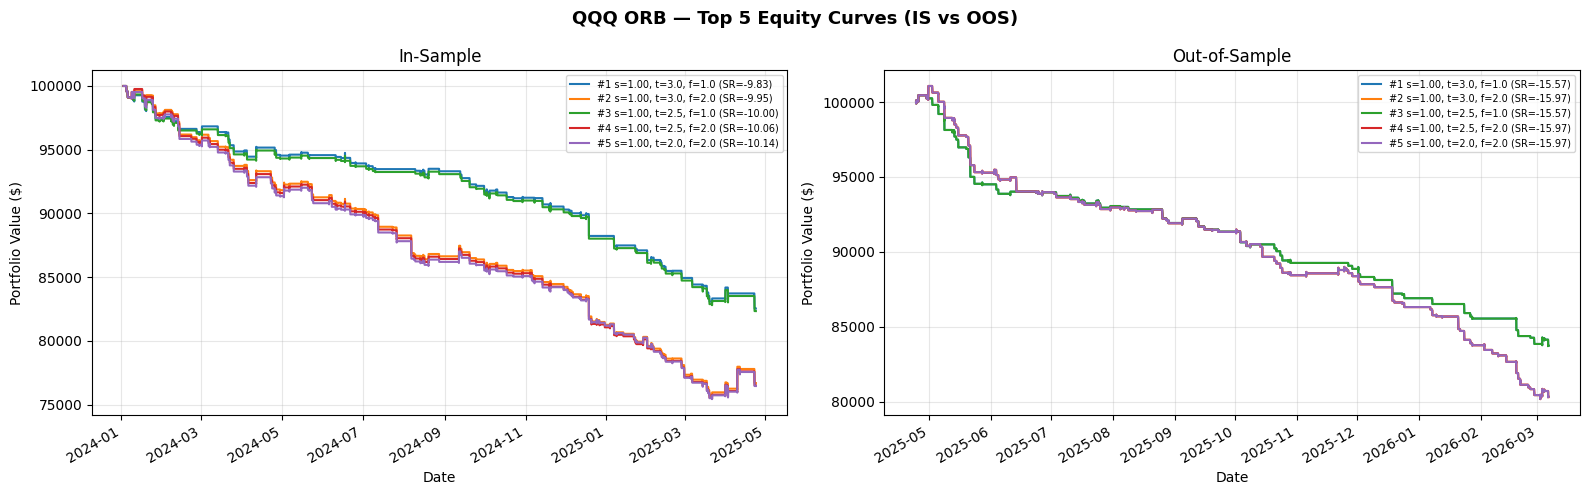

In [11]:
# ═══════════════════════════════════════════════════════════════
# TOP 5 OOS VALIDATION
# ═══════════════════════════════════════════════════════════════

top5 = results_df.head(5).copy()
val_data_raw = stock_data.loc[val_df.index[0]:val_df.index[-1]].copy()

oos_results = []
is_portfolios = []
oos_portfolios = []

print(f"Validating top 5 IS combos on OOS data...\n")
print(f"{'Rank':<5} {'Params':<30} {'IS Sharpe':>10} {'OOS Sharpe':>11} {'IS Ret':>9} {'OOS Ret':>9} {'IS Trades':>10} {'OOS Trades':>11}")
print("-" * 100)

for rank, (_, row) in enumerate(top5.iterrows()):
    sm = row['stop_mult']
    tm = row['target_mult']
    fm = row['range_filter_mult']
    f_str = f"{fm:.1f}" if fm < 900 else "OFF"
    param_str = f"s={sm:.2f}, t={tm:.1f}, f={f_str}"

    # IS portfolio (re-run for equity curve)
    ent_is, ext_is = generate_orb_signals(train_data_raw, stop_mult=sm, target_mult=tm, range_filter_mult=fm)
    ent_is = ent_is.reindex(train_close.index, fill_value=False)
    ext_is = ext_is.reindex(train_close.index, fill_value=False)
    pf_is = vbt.Portfolio.from_signals(close=train_close, entries=ent_is, exits=ext_is,
                                        init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
    is_portfolios.append(pf_is)

    # OOS portfolio
    ent_oos, ext_oos = generate_orb_signals(val_data_raw, stop_mult=sm, target_mult=tm, range_filter_mult=fm)
    ent_oos = ent_oos.reindex(val_close.index, fill_value=False)
    ext_oos = ext_oos.reindex(val_close.index, fill_value=False)
    pf_oos = vbt.Portfolio.from_signals(close=val_close, entries=ent_oos, exits=ext_oos,
                                         init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
    oos_portfolios.append(pf_oos)

    def safe(fn, default=np.nan):
        try: return float(fn())
        except: return default

    is_sharpe = safe(lambda: pf_is.sharpe_ratio(freq='h'))
    oos_sharpe = safe(lambda: pf_oos.sharpe_ratio(freq='h'))
    is_ret = safe(pf_is.total_return)
    oos_ret = safe(pf_oos.total_return)
    is_trades = pf_is.trades.count()
    oos_trades = pf_oos.trades.count()

    oos_results.append({
        'rank': rank + 1, 'params': param_str,
        'stop_mult': sm, 'target_mult': tm, 'range_filter_mult': fm,
        'is_sharpe': is_sharpe, 'oos_sharpe': oos_sharpe,
        'is_return': is_ret, 'oos_return': oos_ret,
        'is_trades': is_trades, 'oos_trades': oos_trades,
    })

    print(f"{rank+1:<5} {param_str:<30} {is_sharpe:>10.3f} {oos_sharpe:>11.3f} "
          f"{is_ret:>9.2%} {oos_ret:>9.2%} {is_trades:>10} {oos_trades:>11}")

# Best params (best OOS Sharpe among top 5)
oos_df = pd.DataFrame(oos_results)
best_oos_idx = oos_df['oos_sharpe'].idxmax()
BEST_STOP = oos_df.loc[best_oos_idx, 'stop_mult']
BEST_TARGET = oos_df.loc[best_oos_idx, 'target_mult']
BEST_FILTER = oos_df.loc[best_oos_idx, 'range_filter_mult']
print(f"\nBest OOS combo: stop={BEST_STOP:.2f}, target={BEST_TARGET:.1f}, filter={BEST_FILTER}")

# Plot equity curves
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{TICKER} ORB — Top 5 Equity Curves (IS vs OOS)', fontsize=13, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i in range(len(is_portfolios)):
    r = oos_results[i]
    is_portfolios[i].value().plot(ax=axes[0], color=colors[i], linewidth=1.5,
                                   label=f"#{r['rank']} {r['params']} (SR={r['is_sharpe']:.2f})")
    oos_portfolios[i].value().plot(ax=axes[1], color=colors[i], linewidth=1.5,
                                    label=f"#{r['rank']} {r['params']} (SR={r['oos_sharpe']:.2f})")

axes[0].set_title('In-Sample')
axes[0].set_ylabel('Portfolio Value ($)')
axes[0].legend(fontsize=7)
axes[0].grid(alpha=0.3)

axes[1].set_title('Out-of-Sample')
axes[1].set_ylabel('Portfolio Value ($)')
axes[1].legend(fontsize=7)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Sensitivity Analysis

How sensitive is the strategy's performance to each parameter? We sweep each parameter individually while holding others at the best values.

**Interpretation:**
- Flat bars across values = **LOW** sensitivity (robust, good)
- Large swings across values = **HIGH** sensitivity (fragile, concerning)

Color coding:
- Dark green: >+10% improvement vs base
- Light green: 0-10% improvement
- Orange: 0-10% degradation
- Red: >10% degradation

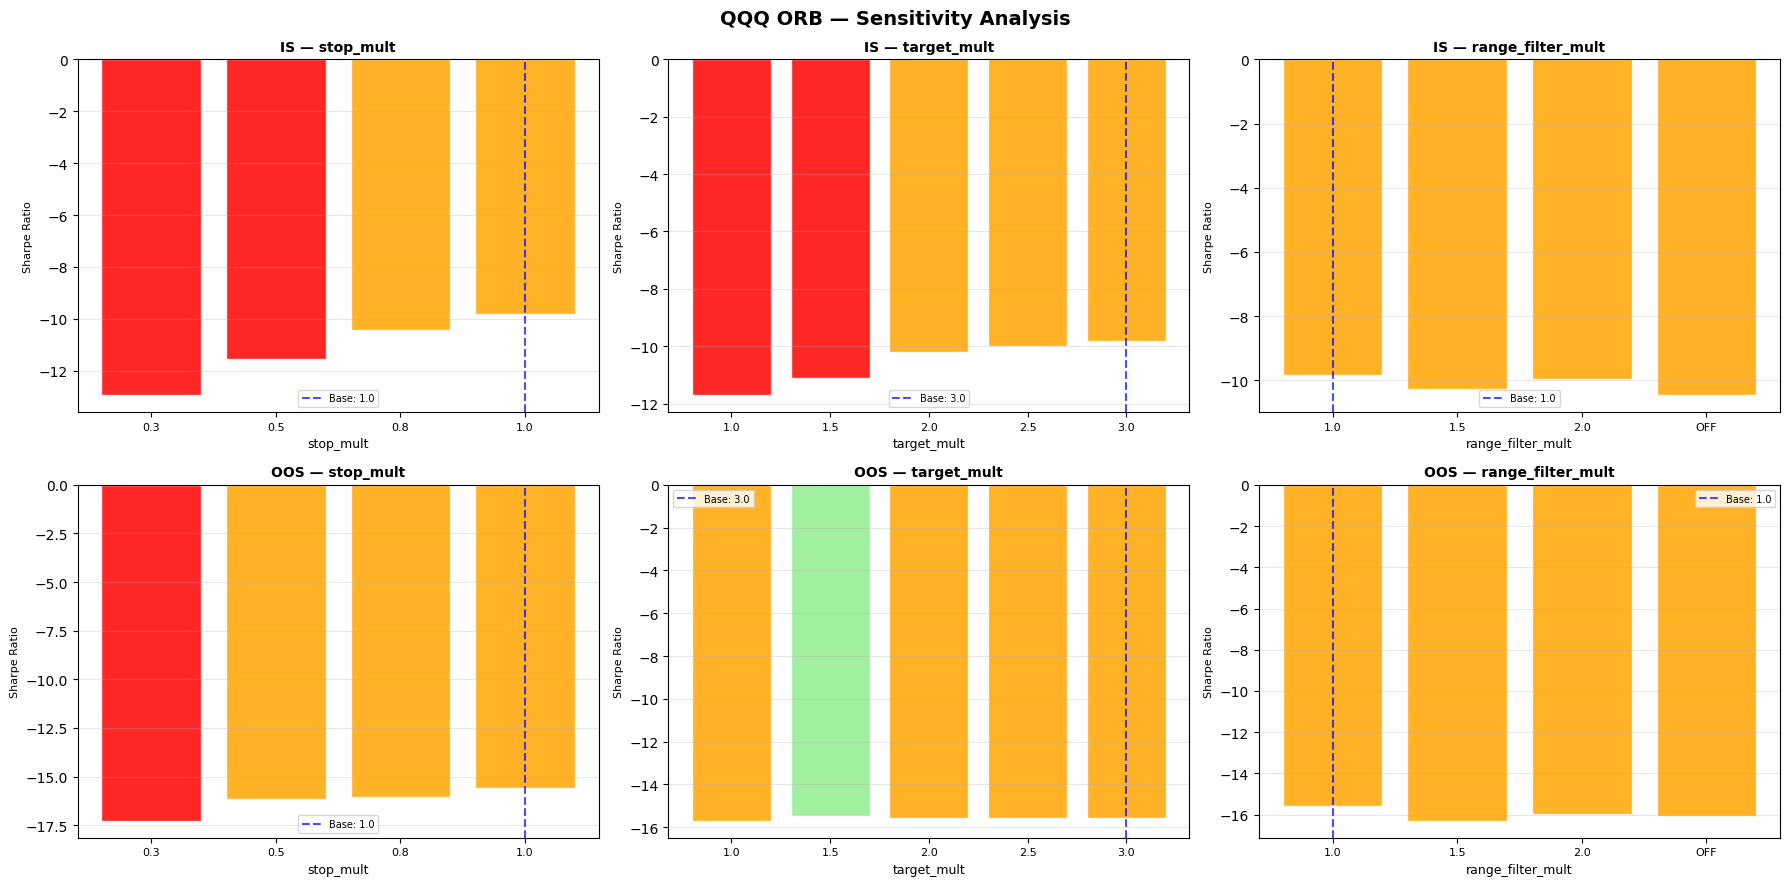


SENSITIVITY SUMMARY:
Parameter                   IS Range  OOS Range  Sensitivity       Flag
----------------------------------------------------------------------
stop_mult                      3.120      1.714        0.176        LOW
target_mult                    1.882      0.216        0.080        LOW
range_filter_mult              0.641      0.738        0.053        LOW


In [12]:
# ═══════════════════════════════════════════════════════════════
# SENSITIVITY ANALYSIS — Bar Charts (2x3 grid: IS row, OOS row)
# ═══════════════════════════════════════════════════════════════

def run_sensitivity(data_raw, close_series, param_name, param_values, base_params):
    """Sweep one parameter, hold others at base values."""
    sharpes = []
    for val in param_values:
        params = base_params.copy()
        params[param_name] = val
        try:
            ent, ext = generate_orb_signals(data_raw, **params)
            ent = ent.reindex(close_series.index, fill_value=False)
            ext = ext.reindex(close_series.index, fill_value=False)
            pf = vbt.Portfolio.from_signals(close=close_series, entries=ent, exits=ext,
                                             init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
            sr = float(pf.sharpe_ratio(freq='h'))
            sharpes.append(sr if not np.isnan(sr) else 0.0)
        except:
            sharpes.append(0.0)
    return sharpes

base_params = {'stop_mult': BEST_STOP, 'target_mult': BEST_TARGET, 'range_filter_mult': BEST_FILTER}

param_configs = [
    ('stop_mult', stop_mult_range, BEST_STOP),
    ('target_mult', target_mult_range, BEST_TARGET),
    ('range_filter_mult', range_filter_range, BEST_FILTER),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(f'{TICKER} ORB — Sensitivity Analysis', fontsize=14, fontweight='bold')

sensitivity_summary = []

for col, (pname, pvalues, base_val) in enumerate(param_configs):
    # IS
    is_sharpes = run_sensitivity(train_data_raw, train_close, pname, pvalues, base_params)
    # OOS
    oos_sharpes = run_sensitivity(val_data_raw, val_close, pname, pvalues, base_params)

    base_is = is_sharpes[pvalues.index(base_val)] if base_val in pvalues else np.mean(is_sharpes)
    base_oos = oos_sharpes[pvalues.index(base_val)] if base_val in pvalues else np.mean(oos_sharpes)

    for row_idx, (sharpes, title_prefix, base_sr) in enumerate([
        (is_sharpes, 'IS', base_is), (oos_sharpes, 'OOS', base_oos)
    ]):
        ax = axes[row_idx][col]
        x_labels = [f"{v:.1f}" if v < 900 else "OFF" for v in pvalues]
        x = np.arange(len(pvalues))

        # Color bars by relative performance vs base
        bar_colors = []
        for sr in sharpes:
            if base_sr != 0:
                pct_diff = (sr - base_sr) / abs(base_sr) * 100
            else:
                pct_diff = 0
            if pct_diff > 10:
                bar_colors.append('darkgreen')
            elif pct_diff > 0:
                bar_colors.append('lightgreen')
            elif pct_diff > -10:
                bar_colors.append('orange')
            else:
                bar_colors.append('red')

        ax.bar(x, sharpes, color=bar_colors, edgecolor='white', alpha=0.85)

        # Blue dashed line at base value
        base_idx = pvalues.index(base_val) if base_val in pvalues else None
        if base_idx is not None:
            ax.axvline(base_idx, color='blue', linestyle='--', linewidth=1.5, alpha=0.7, label=f'Base: {base_val}')
            ax.legend(fontsize=7)

        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, fontsize=8)
        ax.set_xlabel(pname, fontsize=9)
        ax.set_ylabel('Sharpe Ratio', fontsize=8)
        ax.set_title(f'{title_prefix} — {pname}', fontsize=10, fontweight='bold')
        ax.grid(alpha=0.3, axis='y')

    # Sensitivity flag
    is_range = max(is_sharpes) - min(is_sharpes)
    oos_range = max(oos_sharpes) - min(oos_sharpes)
    avg_sr = np.mean(is_sharpes + oos_sharpes)
    sensitivity = (is_range + oos_range) / 2 / max(abs(avg_sr), 0.01)
    flag = "LOW" if sensitivity < 0.5 else "HIGH"
    sensitivity_summary.append((pname, is_range, oos_range, sensitivity, flag))

plt.tight_layout()
plt.show()

# Print summary table
print(f"\nSENSITIVITY SUMMARY:")
print(f"{'Parameter':<25} {'IS Range':>10} {'OOS Range':>10} {'Sensitivity':>12} {'Flag':>10}")
print("-" * 70)
for pname, is_r, oos_r, sens, flag in sensitivity_summary:
    flag_emoji = "LOW" if flag == "LOW" else "HIGH"
    print(f"{pname:<25} {is_r:>10.3f} {oos_r:>10.3f} {sens:>12.3f} {flag_emoji:>10}")

Multi-Asset OOS Validation — ORB params: stop=1.00, target=3.0, filter=1.0
Ticker    IS Sharpe  OOS Sharpe  IS Trades  OOS Trades  OOS Return  OOS MaxDD   OOS WR   OOS PF
--------------------------------------------------------------------------------------------------------------
QQQ          -9.831     -15.565        100          71     -16.29%    -16.67%    14.1%     0.10
SPY         -13.802     -16.101        107          72     -14.12%    -14.41%    13.9%     0.09
NVDA         -3.523      -8.828         82          48     -17.51%    -17.51%    20.8%     0.15
AAPL         -4.711     -10.318         69          38     -11.69%    -11.98%    15.8%     0.08
MSFT         -6.891      -8.909         79          51     -10.83%    -11.21%    27.5%     0.25
AMD          -4.744      -8.096         75          37     -15.36%    -15.44%    24.3%     0.26
META         -7.066      -9.872         85          54     -14.30%    -14.88%    20.4%     0.24
AMZN         -5.648      -9.187         81    

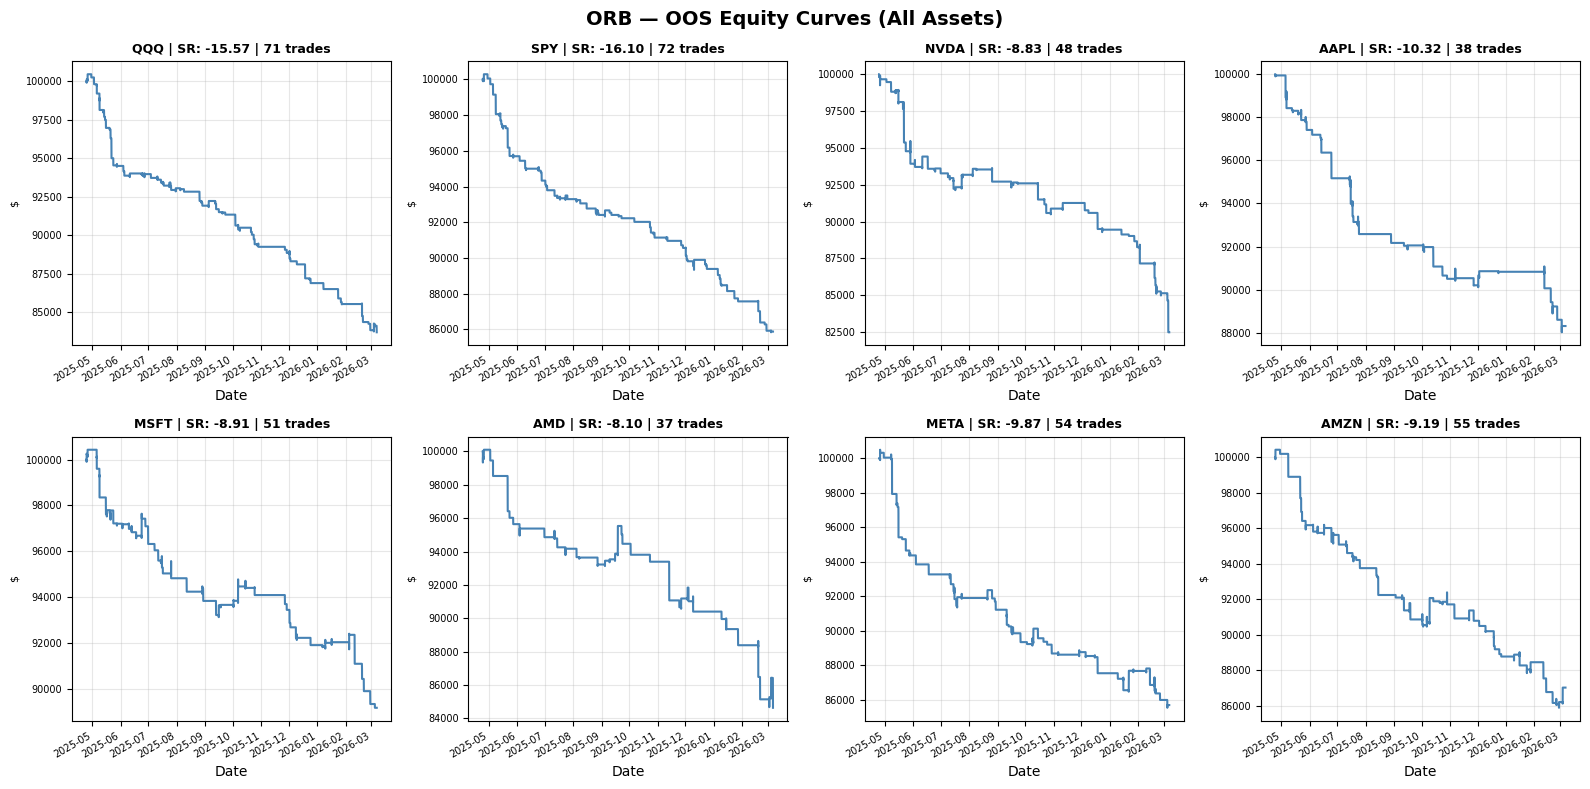


Assets with OOS trades: 8/8
Total OOS trades: 426
Average OOS Sharpe: -10.860


In [13]:
# ═══════════════════════════════════════════════════════════════
# MULTI-ASSET OOS VALIDATION — Best Params Across All 8 Tickers
# ═══════════════════════════════════════════════════════════════

print(f"Multi-Asset OOS Validation — ORB params: stop={BEST_STOP:.2f}, target={BEST_TARGET:.1f}, filter={BEST_FILTER}")
print(f"{'='*110}")
print(f"{'Ticker':<8} {'IS Sharpe':>10} {'OOS Sharpe':>11} {'IS Trades':>10} {'OOS Trades':>11} "
      f"{'OOS Return':>11} {'OOS MaxDD':>10} {'OOS WR':>8} {'OOS PF':>8}")
print(f"{'-'*110}")

multi_results = []
multi_portfolios = {}

for ticker in TICKERS:
    if ticker not in all_data:
        print(f"{ticker:<8} — NO DATA")
        continue

    t_data = all_data[ticker].copy()

    # Filter to market hours
    t_data_mkt = t_data.copy()
    t_data_mkt['hour_utc'] = t_data_mkt.index.hour
    t_data_mkt = t_data_mkt[(t_data_mkt['hour_utc'] >= 14) & (t_data_mkt['hour_utc'] <= 19)].copy()
    t_data_mkt = t_data_mkt.drop(columns=['hour_utc'])

    t_close = t_data_mkt['Close'].astype(float)
    t_split = int(len(t_close) * TRAIN_RATIO)
    t_train_close = t_close.iloc[:t_split]
    t_val_close = t_close.iloc[t_split:]

    t_train_raw = t_data.loc[t_data_mkt.index[0]:t_data_mkt.index[t_split - 1]].copy()
    t_val_raw = t_data.loc[t_data_mkt.index[t_split]:t_data_mkt.index[-1]].copy()

    def safe(fn, default=np.nan):
        try: return float(fn())
        except: return default

    # IS
    try:
        e_is, x_is = generate_orb_signals(t_train_raw, stop_mult=BEST_STOP, target_mult=BEST_TARGET, range_filter_mult=BEST_FILTER)
        e_is = e_is.reindex(t_train_close.index, fill_value=False)
        x_is = x_is.reindex(t_train_close.index, fill_value=False)
        pf_is = vbt.Portfolio.from_signals(close=t_train_close, entries=e_is, exits=x_is,
                                            init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
        is_sr = safe(lambda: pf_is.sharpe_ratio(freq='h'))
        is_trades = pf_is.trades.count()
    except:
        pf_is = None; is_sr = np.nan; is_trades = 0

    # OOS
    try:
        e_oos, x_oos = generate_orb_signals(t_val_raw, stop_mult=BEST_STOP, target_mult=BEST_TARGET, range_filter_mult=BEST_FILTER)
        e_oos = e_oos.reindex(t_val_close.index, fill_value=False)
        x_oos = x_oos.reindex(t_val_close.index, fill_value=False)
        pf_oos = vbt.Portfolio.from_signals(close=t_val_close, entries=e_oos, exits=x_oos,
                                              init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq='h')
        oos_sr = safe(lambda: pf_oos.sharpe_ratio(freq='h'))
        oos_ret = safe(pf_oos.total_return)
        oos_dd = safe(pf_oos.max_drawdown)
        oos_trades = pf_oos.trades.count()

        tr = np.asarray(pf_oos.trades.returns.values if hasattr(pf_oos.trades.returns, 'values') else pf_oos.trades.returns).ravel()
        pos = tr[tr > 0]; neg = tr[tr < 0]
        oos_wr = float(len(pos) / len(tr) * 100) if len(tr) > 0 else np.nan
        oos_pf = float(pos.sum() / abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else np.nan
    except:
        pf_oos = None; oos_sr = np.nan; oos_ret = np.nan; oos_dd = np.nan
        oos_trades = 0; oos_wr = np.nan; oos_pf = np.nan

    multi_results.append({
        'ticker': ticker, 'is_sharpe': is_sr, 'oos_sharpe': oos_sr,
        'is_trades': is_trades, 'oos_trades': oos_trades,
        'oos_return': oos_ret, 'oos_maxdd': oos_dd,
        'oos_win_rate': oos_wr, 'oos_pf': oos_pf,
    })
    multi_portfolios[ticker] = {'is': pf_is, 'oos': pf_oos}

    is_str = f"{is_sr:.3f}" if not np.isnan(is_sr) else "N/A"
    oos_sr_str = f"{oos_sr:.3f}" if not np.isnan(oos_sr) else "N/A"
    oos_ret_str = f"{oos_ret:.2%}" if not np.isnan(oos_ret) else "N/A"
    oos_dd_str = f"{oos_dd:.2%}" if not np.isnan(oos_dd) else "N/A"
    oos_wr_str = f"{oos_wr:.1f}%" if not np.isnan(oos_wr) else "N/A"
    oos_pf_str = f"{oos_pf:.2f}" if not np.isnan(oos_pf) else "N/A"

    print(f"{ticker:<8} {is_str:>10} {oos_sr_str:>11} {is_trades:>10} {oos_trades:>11} "
          f"{oos_ret_str:>11} {oos_dd_str:>10} {oos_wr_str:>8} {oos_pf_str:>8}")

# Plot OOS equity curves for all assets
n_assets = len([r for r in multi_results if multi_portfolios[r['ticker']]['oos'] is not None])
cols = 4
rows = max((len(TICKERS) + cols - 1) // cols, 1)
fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
fig.suptitle(f'ORB — OOS Equity Curves (All Assets)', fontsize=14, fontweight='bold')
if rows == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.flatten()

for i, ticker in enumerate(TICKERS):
    ax = axes_flat[i]
    pf_oos = multi_portfolios.get(ticker, {}).get('oos')
    r = [x for x in multi_results if x['ticker'] == ticker]

    if pf_oos is not None and r:
        pf_oos.value().plot(ax=ax, color='steelblue', linewidth=1.5)
        sr = r[0]['oos_sharpe']
        tr = r[0]['oos_trades']
        sr_str = f"{sr:.2f}" if not np.isnan(sr) else "N/A"
        ax.set_title(f'{ticker} | SR: {sr_str} | {tr} trades', fontsize=9, fontweight='bold')
    else:
        ax.text(0.5, 0.5, 'No trades', ha='center', va='center', fontsize=12, color='gray')
        ax.set_title(f'{ticker} | No trades', fontsize=9)

    ax.grid(alpha=0.3)
    ax.set_ylabel('$', fontsize=8)
    ax.tick_params(labelsize=7)

for i in range(len(TICKERS), len(axes_flat)):
    axes_flat[i].set_visible(False)

plt.tight_layout()
plt.show()

# Summary
valid_oos = [r for r in multi_results if not np.isnan(r.get('oos_sharpe', np.nan)) and r['oos_trades'] > 0]
print(f"\nAssets with OOS trades: {len(valid_oos)}/{len(TICKERS)}")
print(f"Total OOS trades: {sum(r['oos_trades'] for r in valid_oos)}")
if valid_oos:
    print(f"Average OOS Sharpe: {np.mean([r['oos_sharpe'] for r in valid_oos]):.3f}")

FTMO rules loaded from config/ftmo_rules.json

FTMO Monte Carlo — 10,000 paths x 30 days
Based on QQQ OOS daily returns (218 days)
Metric                              Value
-------------------------------------------------------
Pass Rate                            0.0%
Fail (daily DD)                      0.0%
Fail (total DD)                      0.0%
Fail (time expired)                100.0%
Mean Final P&L            $        -2,441
Median Final P&L          $        -2,352
5th Percentile P&L        $        -4,495
95th Percentile P&L       $          -715


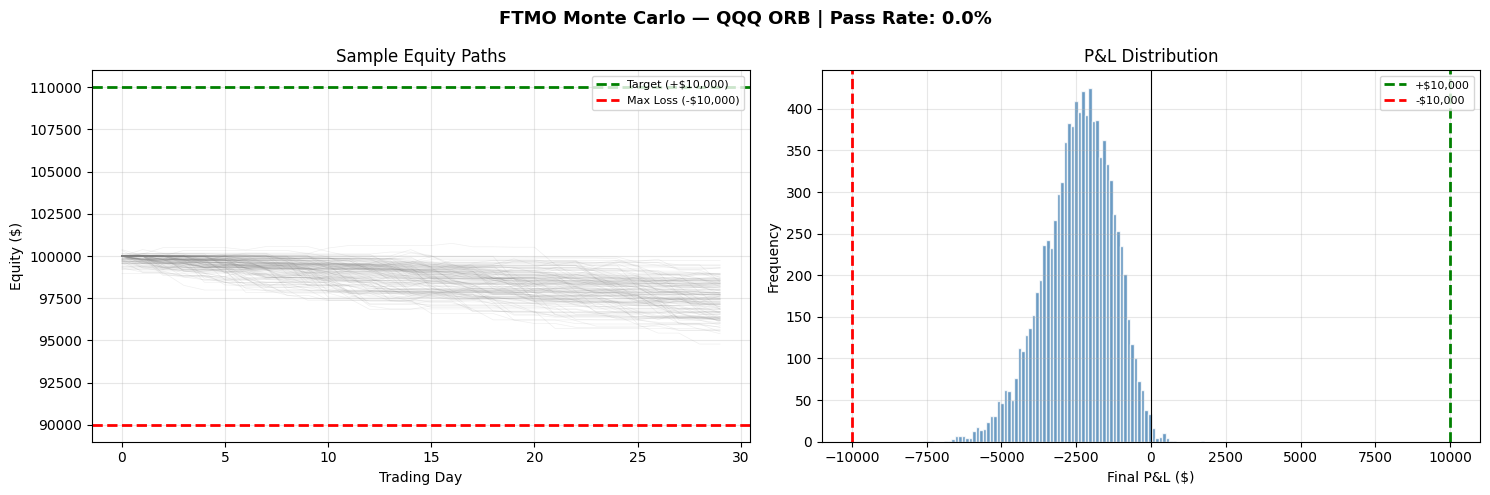

In [14]:
# ═══════════════════════════════════════════════════════════════
# FTMO MONTE CARLO SIMULATION — 10,000 paths x 30 days
# ═══════════════════════════════════════════════════════════════
# Uses OOS hourly returns aggregated to daily returns

import json

# Load FTMO rules from config
try:
    with open(os.path.join('..', 'config', 'ftmo_rules.json'), 'r', encoding='utf-8') as f:
        ftmo_cfg = json.load(f)
    FTMO_ACCOUNT = ftmo_cfg['account_size']
    FTMO_PROFIT_TARGET = ftmo_cfg['profit_target_pct'] / 100
    FTMO_MAX_DAILY_DD = ftmo_cfg['max_daily_loss_pct'] / 100
    FTMO_MAX_TOTAL_DD = ftmo_cfg['max_total_loss_pct'] / 100
    FTMO_CHALLENGE_DAYS = ftmo_cfg['challenge_days']
    print("FTMO rules loaded from config/ftmo_rules.json")
except:
    FTMO_ACCOUNT = 100_000
    FTMO_PROFIT_TARGET = 0.10
    FTMO_MAX_DAILY_DD = 0.05
    FTMO_MAX_TOTAL_DD = 0.10
    FTMO_CHALLENGE_DAYS = 30
    print("Using default FTMO rules")

MONTE_CARLO_PATHS = 10_000

# Get OOS portfolio for primary ticker
pf_primary_oos = oos_portfolios[0] if oos_portfolios else None

# Aggregate hourly returns to daily returns
if pf_primary_oos is not None and pf_primary_oos.trades.count() > 0:
    hourly_rets = pf_primary_oos.returns()
    # Group by date and compound
    hourly_rets_df = hourly_rets.to_frame('ret')
    hourly_rets_df['date'] = hourly_rets_df.index.date
    daily_rets_oos = hourly_rets_df.groupby('date')['ret'].apply(lambda x: (1 + x).prod() - 1).values
    daily_rets_oos = daily_rets_oos[~np.isnan(daily_rets_oos)]

    account = FTMO_ACCOUNT
    target = account * FTMO_PROFIT_TARGET
    max_daily = account * FTMO_MAX_DAILY_DD
    max_total = account * FTMO_MAX_TOTAL_DD
    n_days = FTMO_CHALLENGE_DAYS
    n_paths = MONTE_CARLO_PATHS

    pass_count = fail_daily = fail_total = fail_time = 0
    final_pnls = []
    sample_paths = []

    np.random.seed(42)
    for s in range(n_paths):
        sampled = np.random.choice(daily_rets_oos, size=n_days, replace=True)
        daily_pnl = account * sampled
        cumulative_pnl = np.cumsum(daily_pnl)
        equity = account + cumulative_pnl

        hit_target = np.any(cumulative_pnl >= target)
        worst_daily = np.min(daily_pnl)
        max_dd_path = np.max(np.maximum.accumulate(equity) - equity)

        if worst_daily <= -max_daily:
            fail_daily += 1
        elif max_dd_path >= max_total:
            fail_total += 1
        elif hit_target:
            pass_count += 1
        else:
            fail_time += 1

        final_pnls.append(cumulative_pnl[-1])
        if s < 150:
            sample_paths.append(equity)

    pass_rate = pass_count / n_paths
    final_pnls = np.array(final_pnls)

    print(f"\nFTMO Monte Carlo — {n_paths:,} paths x {n_days} days")
    print(f"Based on {TICKER} OOS daily returns ({len(daily_rets_oos)} days)")
    print(f"{'='*55}")
    print(f"{'Metric':<25} {'Value':>15}")
    print(f"{'-'*55}")
    print(f"{'Pass Rate':<25} {pass_rate:>15.1%}")
    print(f"{'Fail (daily DD)':<25} {fail_daily/n_paths:>15.1%}")
    print(f"{'Fail (total DD)':<25} {fail_total/n_paths:>15.1%}")
    print(f"{'Fail (time expired)':<25} {fail_time/n_paths:>15.1%}")
    print(f"{'Mean Final P&L':<25} ${final_pnls.mean():>14,.0f}")
    print(f"{'Median Final P&L':<25} ${np.median(final_pnls):>14,.0f}")
    print(f"{'5th Percentile P&L':<25} ${np.percentile(final_pnls, 5):>14,.0f}")
    print(f"{'95th Percentile P&L':<25} ${np.percentile(final_pnls, 95):>14,.0f}")

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'FTMO Monte Carlo — {TICKER} ORB | Pass Rate: {pass_rate:.1%}', fontsize=13, fontweight='bold')

    for path in sample_paths:
        c = 'green' if path[-1] >= account + target else ('red' if path[-1] <= account - max_total else 'gray')
        axes[0].plot(path, color=c, alpha=0.12, linewidth=0.5)
    axes[0].axhline(account + target, color='green', linestyle='--', linewidth=2, label=f'Target (+${target:,.0f})')
    axes[0].axhline(account - max_total, color='red', linestyle='--', linewidth=2, label=f'Max Loss (-${max_total:,.0f})')
    axes[0].set_xlabel('Trading Day')
    axes[0].set_ylabel('Equity ($)')
    axes[0].set_title('Sample Equity Paths')
    axes[0].legend(fontsize=8)
    axes[0].grid(alpha=0.3)

    axes[1].hist(final_pnls, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
    axes[1].axvline(target, color='green', linestyle='--', linewidth=2, label=f'+${target:,.0f}')
    axes[1].axvline(-max_total, color='red', linestyle='--', linewidth=2, label=f'-${max_total:,.0f}')
    axes[1].axvline(0, color='black', linewidth=0.8)
    axes[1].set_xlabel('Final P&L ($)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('P&L Distribution')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("Cannot run FTMO Monte Carlo — no OOS trades for primary ticker.")

In [15]:
# ════════════════════════════════════════════════════════════════════
# UNIVERSAL STRATEGY EXPORT — Data Files + PDF Tearsheet
# ════════════════════════════════════════════════════════════════════
# INSTRUCTIONS:
#   1. Paste at the END of any strategy notebook
#   2. Edit STRATEGY_NAME and PARAM_COLS below
#   3. Run — exports structured data + a comprehensive PDF report
# ════════════════════════════════════════════════════════════════════

import os, sys, json, datetime, hashlib, platform
from matplotlib.backends.backend_pdf import PdfPages

# ═══ EDIT THESE LINES ═══════════════════════════════════════
STRATEGY_NAME = "Opening_Range_Breakout"                              # ← EDIT
PARAM_COLS    = ["stop_mult", "target_mult", "range_filter_mult"]    # ← EDIT
NOTES         = ""                                                    # ← Optional run notes
# ════════════════════════════════════════════════════════════════

FREQ = 'h'  # Hourly frequency for this intraday strategy

# ── Google Drive mount ──
EXPORT_DIR = "/content/strategy_exports"
IN_COLAB = 'google.colab' in sys.modules
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    EXPORT_DIR = "/content/drive/MyDrive/strategy_exports"
    IN_COLAB = True
    print("Google Drive mounted")
except:
    print("Local mode — exports to ./strategy_exports")

RUN_TIMESTAMP = datetime.datetime.now()
RUN_ID = RUN_TIMESTAMP.strftime("%Y%m%d_%H%M%S")

# ── Folder structure ──
STRAT_DIR   = os.path.join(EXPORT_DIR, STRATEGY_NAME, TICKER)
LATEST_DIR  = os.path.join(STRAT_DIR, "latest")
ARCHIVE_DIR = os.path.join(STRAT_DIR, "archive")
os.makedirs(LATEST_DIR, exist_ok=True)
os.makedirs(ARCHIVE_DIR, exist_ok=True)

# ════════════════════════════════════════════════════════════════
# Build portfolios for export
# ════════════════════════════════════════════════════════════════
best_params = {
    'stop_mult': BEST_STOP,
    'target_mult': BEST_TARGET,
    'range_filter_mult': BEST_FILTER,
}
param_str = ", ".join([f"{k}={v}" for k, v in best_params.items()])

# Full sample
full_close = hourly_close.copy()
full_close.name = 'price'

e_full, x_full = generate_orb_signals(stock_data, **best_params)
e_full = e_full.reindex(full_close.index, fill_value=False)
x_full = x_full.reindex(full_close.index, fill_value=False)
pf_full = vbt.Portfolio.from_signals(close=full_close, entries=e_full, exits=x_full,
                                      init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq=FREQ)

# IS
e_is_exp, x_is_exp = generate_orb_signals(train_data_raw, **best_params)
e_is_exp = e_is_exp.reindex(train_close.index, fill_value=False)
x_is_exp = x_is_exp.reindex(train_close.index, fill_value=False)
pf_is = vbt.Portfolio.from_signals(close=train_close, entries=e_is_exp, exits=x_is_exp,
                                    init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq=FREQ)

# OOS
e_oos_exp, x_oos_exp = generate_orb_signals(val_data_raw, **best_params)
e_oos_exp = e_oos_exp.reindex(val_close.index, fill_value=False)
x_oos_exp = x_oos_exp.reindex(val_close.index, fill_value=False)
pf_oos = vbt.Portfolio.from_signals(close=val_close, entries=e_oos_exp, exits=x_oos_exp,
                                     init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq=FREQ)

# Buy & Hold
bh_e = pd.Series(False, index=full_close.index, dtype=bool); bh_e.iloc[0] = True
bh_x = pd.Series(False, index=full_close.index, dtype=bool)
pf_bh = vbt.Portfolio.from_signals(close=full_close, entries=bh_e, exits=bh_x,
                                    init_cash=INIT_CASH, fees=FEES, slippage=SLIPPAGE, freq=FREQ)

# ── Extract metrics ──
trades_obj = pf_full.trades
tr = np.asarray(trades_obj.returns.values if hasattr(trades_obj.returns, 'values') else trades_obj.returns).ravel()
pnl = np.asarray(trades_obj.pnl.values if hasattr(trades_obj.pnl, 'values') else trades_obj.pnl).ravel()
pos, neg = tr[tr > 0], tr[tr < 0]
hours_full = len(full_close)
trading_days_full = hours_full / 6
years_full = max(trading_days_full / 252, 1e-9)
daily_rets = pf_full.returns()

def safe(fn, default=None):
    try: return float(fn())
    except: return default

M = {
    'total_return': safe(pf_full.total_return), 'ann_return': safe(lambda: pf_full.annualized_return(freq=FREQ)),
    'sharpe': safe(lambda: pf_full.sharpe_ratio(freq=FREQ)), 'sortino': safe(lambda: pf_full.sortino_ratio(freq=FREQ)),
    'max_dd': safe(pf_full.max_drawdown), 'volatility': safe(lambda: pf_full.annualized_volatility(freq=FREQ)),
    'calmar': safe(lambda: pf_full.annualized_return(freq=FREQ)) / abs(safe(pf_full.max_drawdown)) if abs(safe(pf_full.max_drawdown, 0)) > 1e-9 else None,
    'trades': len(trades_obj), 'trades_yr': len(trades_obj) / years_full,
    'win_rate': float(len(pos) / len(tr) * 100) if len(tr) > 0 else None,
    'pf': float(pos.sum() / abs(neg.sum())) if len(neg) > 0 and abs(neg.sum()) > 0 else None,
    'expectancy': float(tr.mean()) if len(tr) > 0 else None,
    'avg_win': float(pos.mean()) if len(pos) > 0 else None, 'avg_loss': float(neg.mean()) if len(neg) > 0 else None,
    'largest_win': float(pos.max()) if len(pos) > 0 else None, 'largest_loss': float(neg.min()) if len(neg) > 0 else None,
    'payoff': float(abs(pos.mean() / neg.mean())) if len(pos) > 0 and len(neg) > 0 else None,
    'is_sharpe': safe(lambda: pf_is.sharpe_ratio(freq=FREQ)), 'is_return': safe(pf_is.total_return),
    'is_dd': safe(pf_is.max_drawdown), 'is_trades': len(pf_is.trades),
    'oos_sharpe': safe(lambda: pf_oos.sharpe_ratio(freq=FREQ)), 'oos_return': safe(pf_oos.total_return),
    'oos_dd': safe(pf_oos.max_drawdown), 'oos_trades': len(pf_oos.trades),
    'bh_return': safe(pf_bh.total_return), 'bh_sharpe': safe(lambda: pf_bh.sharpe_ratio(freq=FREQ)),
    'bh_dd': safe(pf_bh.max_drawdown),
}

# ════════════════════════════════════════════════════════════════
# 1. SAVE STRUCTURED DATA FILES
# ════════════════════════════════════════════════════════════════
export_json = {
    "metadata": {
        "run_id": RUN_ID, "export_timestamp": RUN_TIMESTAMP.isoformat(),
        "strategy_name": STRATEGY_NAME, "strategy_family": "ORB",
        "ticker": TICKER,
        "data_source": "alpaca", "data_interval": "1h", "currency": "USD",
        "start_date": str(full_close.index[0].date()), "end_date": str(full_close.index[-1].date()),
        "total_bars": len(full_close), "total_years": round(years_full, 2),
        "train_bars": len(train_close), "val_bars": len(val_close), "train_ratio": TRAIN_RATIO,
        "init_cash": INIT_CASH, "fees_pct": FEES, "slippage_pct": SLIPPAGE, "frequency": FREQ,
        "grid_combos_tested": len(results_df), "param_columns": PARAM_COLS, "notes": NOTES,
    },
    "best_params": best_params,
    "metrics_full_sample": {k: v for k, v in M.items() if not k.startswith('is_') and not k.startswith('oos_') and not k.startswith('bh_')},
    "metrics_in_sample": {k.replace('is_',''): v for k, v in M.items() if k.startswith('is_')},
    "metrics_out_of_sample": {k.replace('oos_',''): v for k, v in M.items() if k.startswith('oos_')},
    "metrics_buy_hold": {k.replace('bh_',''): v for k, v in M.items() if k.startswith('bh_')},
}

# Add Monte Carlo results if available
if 'pass_rate' in dir():
    export_json['ftmo_monte_carlo'] = {
        'n_paths': MONTE_CARLO_PATHS,
        'n_days': FTMO_CHALLENGE_DAYS,
        'pass_rate': pass_rate,
        'fail_daily_dd': fail_daily / n_paths,
        'fail_total_dd': fail_total / n_paths,
        'fail_time': fail_time / n_paths,
        'mean_final_pnl': float(final_pnls.mean()),
        'median_final_pnl': float(np.median(final_pnls)),
    }

# Save JSON
json_path = os.path.join(LATEST_DIR, "summary.json")
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(export_json, f, indent=2, default=str)
print(f"Saved: {json_path}")

# Save daily returns
daily_rets_export = pf_full.returns()
daily_rets_export.to_csv(os.path.join(LATEST_DIR, "daily_returns.csv"))
print(f"Saved: daily_returns.csv")

# Save grid results
results_df.to_csv(os.path.join(LATEST_DIR, "grid_results.csv"), index=False)
print(f"Saved: grid_results.csv ({len(results_df)} rows)")

# Archive
import shutil
archive_json = os.path.join(ARCHIVE_DIR, f"{RUN_ID}_summary.json")
shutil.copy2(json_path, archive_json)
print(f"Archived: {archive_json}")

print(f"\nExport complete for {STRATEGY_NAME} / {TICKER}")
print(f"Best params: {param_str}")
print(f"Full-sample Sharpe: {M['sharpe']:.3f}" if M['sharpe'] else "Full-sample Sharpe: N/A")
print(f"IS Sharpe: {M['is_sharpe']:.3f}" if M['is_sharpe'] else "IS Sharpe: N/A")
print(f"OOS Sharpe: {M['oos_sharpe']:.3f}" if M['oos_sharpe'] else "OOS Sharpe: N/A")

Local mode — exports to ./strategy_exports
Saved: /content/strategy_exports\Opening_Range_Breakout\QQQ\latest\summary.json
Saved: daily_returns.csv
Saved: grid_results.csv (80 rows)
Archived: /content/strategy_exports\Opening_Range_Breakout\QQQ\archive\20260308_170657_summary.json

Export complete for Opening_Range_Breakout / QQQ
Best params: stop_mult=1.0, target_mult=3.0, range_filter_mult=1.0
Full-sample Sharpe: -11.542
IS Sharpe: -9.831
OOS Sharpe: -15.565
